# Biometric System Performance Evaluation
**Dataset:** 100 users x 10 image samples each (5 enrollment + 5 test), 144 features per sample.
**Matching distances compared:** Euclidean distance and Cosine similarity.

This notebook produces: (A) Genuine distribution, (B) Impostor distribution, (C) FAR plot,
(D) FRR plot, (E) ROC curves, (F) Equal Error Rate (EER) and Decidability Index, for both
distance metrics, followed by a comparison of which metric performs better.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import cdist
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_curve, auc

plt.style.use("ggplot")
np.set_printoptions(suppress=True)
np.random.seed(0)

## 1. Data Loading & Cleaning

I noticed that data is transpose of what it describes and it is also noticed that last person has only 9 valid samples and not 10

But then noticed that column 0 is also a feature value and is clean and is not to be dropped

In [2]:
FILE_PATH = "biomet_data.csv"

raw_data = pd.read_csv(FILE_PATH, sep="\t", header=None)
print("Original shape:", raw_data.shape)
display(raw_data.iloc[:5, :6])

Original shape: (144, 1001)


,0,1,2,3,4,5
0,307.02177,296.77448,213.03365,195.24468,229.44699,249.84867
1,364.09315,348.58811,331.81183,289.80958,327.11110,327.28334
2,239.10673,238.26485,289.61825,173.42357,281.41246,251.26869
3,206.98782,241.55478,281.39093,219.13554,252.41240,241.61543
4,192.14200,216.70194,245.03126,216.16553,220.47665,208.92883


In [ ]:

print("DATASET VALIDATION")

print(f"Rows: {raw_data.shape[0]}")
print(f"Columns: {raw_data.shape[1]}")
print("\nTotal missing values:", raw_data.isna().sum().sum())

empty_cols = raw_data.columns[raw_data.isna().all(axis=0)].tolist()
print("Fully-empty columns:", empty_cols)

empty_rows = raw_data.index[raw_data.isna().all(axis=1)].tolist()
print("Fully-empty rows:", empty_rows)

DATASET VALIDATION
Rows    : 144
Columns : 1001

Total missing values: 144
Fully-empty columns: [1000]
Fully-empty rows: []


In [ ]:
# Transpose so that rows = samples, columns = features
data = raw_data.T.reset_index(drop=True)
data = data.apply(pd.to_numeric)
data.columns = [f"Feature_{i+1}" for i in range(data.shape[1])]

print("Samples x Features:", data.shape)
display(data.head())

Samples x Features: (1000, 144)


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,...,Feature_135,Feature_136,Feature_137,Feature_138,Feature_139,Feature_140,Feature_141,Feature_142,Feature_143,Feature_144
0,307.02177,364.09315,239.10673,206.98782,192.14200,339.33542,378.60285,331.73323,312.88632,243.36447,...,211.22383,244.01569,152.51256,151.69437,154.11718,149.06571,136.48869,138.14310,171.01205,161.21722
1,296.77448,348.58811,238.26485,241.55478,216.70194,292.16018,340.54587,311.61086,329.02780,229.21348,...,239.05821,258.53250,178.20929,148.15210,160.86317,153.16811,154.24074,160.82182,186.12079,171.02661
2,213.03365,331.81183,289.61825,281.39093,245.03126,337.09025,412.49380,290.51800,336.54955,215.48637,...,257.41436,302.24734,241.98635,175.44978,188.84960,168.49079,169.17194,169.52535,175.06606,178.98578
3,195.24468,289.80958,173.42357,219.13554,216.16553,272.94746,340.95611,269.46268,277.07710,234.22016,...,186.41690,241.72619,237.73706,171.83441,189.91721,147.21565,157.72283,177.64754,186.51449,182.68898
4,229.44699,327.11110,281.41246,252.41240,220.47665,380.33309,391.79664,313.81984,278.82955,256.83308,...,250.04025,280.92582,223.92805,209.27869,199.58926,150.32774,163.49850,175.31746,195.11172,197.30582


## 2. Assign User IDs

In [6]:
user_ids = [i // 10 for i in range(len(data))]
data["UserID"] = user_ids

print("Total users:", data["UserID"].nunique())
counts = data.groupby("UserID").size()
print("Samples per user -> min:", counts.min(), " max:", counts.max())
assert data["UserID"].nunique() == 100 and (counts == 10).all()
print("Confirmed: 100 users x 10 samples each.")

Total users: 100
Samples per user -> min: 10  max: 10
Confirmed: 100 users x 10 samples each.


## 3. Train / Test Split

In [7]:
feature_columns = [c for c in data.columns if c != "UserID"]

train_list, test_list = [], []
for user in sorted(data["UserID"].unique()):
    user_data = data[data["UserID"] == user]
    train_list.append(user_data.iloc[:5])
    test_list.append(user_data.iloc[5:])

train_data = pd.concat(train_list).reset_index(drop=True)
test_data = pd.concat(test_list).reset_index(drop=True)

print("Enrollment samples:", len(train_data))
print("Test samples      :", len(test_data))

Enrollment samples: 500
Test samples      : 500


## 4. Enrollment Templates

Each user's biometric template is the mean feature vector of their 5 enrollment
samples.

In [8]:
templates = train_data.groupby("UserID")[feature_columns].mean()
template_matrix = templates.values.astype(np.float64)     # (100, 144)
test_matrix = test_data[feature_columns].values.astype(np.float64)  # (500, 144)
test_labels = test_data["UserID"].values

print("Template matrix:", template_matrix.shape)
print("Test matrix    :", test_matrix.shape)
display(templates.head())

Template matrix: (100, 144)
Test matrix    : (500, 144)


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,...,Feature_135,Feature_136,Feature_137,Feature_138,Feature_139,Feature_140,Feature_141,Feature_142,Feature_143,Feature_144
UserID,,,,,,,,,,,,,,,,,,,,,
0,248.304314,332.282754,244.365172,240.296294,218.103476,324.373280,372.879054,303.428922,306.874064,235.823512,...,228.830710,265.489508,206.874662,171.281870,178.667284,153.653600,156.224540,164.291054,182.765022,178.244882
1,161.651692,200.897466,230.292628,200.065292,149.260864,125.459454,147.184600,162.596920,156.831840,147.454948,...,140.669180,154.384382,123.095292,127.662398,124.979342,128.553940,119.366232,97.891761,111.905842,113.801203
2,194.570822,183.329496,190.190516,188.239680,234.151304,268.744054,228.342752,174.051886,156.463326,139.347245,...,203.392458,185.199472,129.679046,138.952644,129.580114,115.779844,129.491728,123.345568,130.694358,131.764452
3,156.445394,191.558610,249.507260,350.013422,346.733508,203.891888,162.512840,143.665466,140.041988,123.764612,...,138.257706,156.534814,130.767862,133.114808,130.934364,133.144366,130.071648,117.259136,99.881170,92.334565
4,199.258926,148.863256,139.381896,126.589386,141.694562,161.853336,130.351918,120.687718,117.199878,110.779182,...,139.976906,157.166232,142.744890,124.299002,137.931496,115.468732,95.055829,100.121900,109.700648,109.933362


## 5. Matching Scores

For every test sample we compute its match score against **all 100** templates using both algoss

The score against the test sample's own user is a **genuine** score; scores against all
other 99 templates are **impostor** scores.

In [ ]:
euclid_mat = cdist(test_matrix, template_matrix, metric="euclidean")   # (500, 100)
cosine_mat = cosine_similarity(test_matrix, template_matrix)           # (500, 100)

# mat[0][2] means distance between test sample 0 and template 2
def genuine_impostor(score_mat, labels):
    genuine, impostor = [], []
    for i in range(score_mat.shape[0]):
        row = score_mat[i] # row has all scores for the i-th test sample against all templates
        true_id = labels[i]
        genuine.append(row[true_id])
        impostor.extend(np.delete(row, true_id))
    return np.array(genuine), np.array(impostor)

eu_gen, eu_imp = genuine_impostor(euclid_mat, test_labels)
co_gen, co_imp = genuine_impostor(cosine_mat, test_labels)

print(f"Euclidean -> genuine: {eu_gen.shape[0]}, impostor: {eu_imp.shape[0]}")
print(f"Cosine    -> genuine: {co_gen.shape[0]}, impostor: {co_imp.shape[0]}")

Euclidean -> genuine: 500, impostor: 49500
Cosine    -> genuine: 500, impostor: 49500


## A & B. Genuine vs Impostor Score Distributions

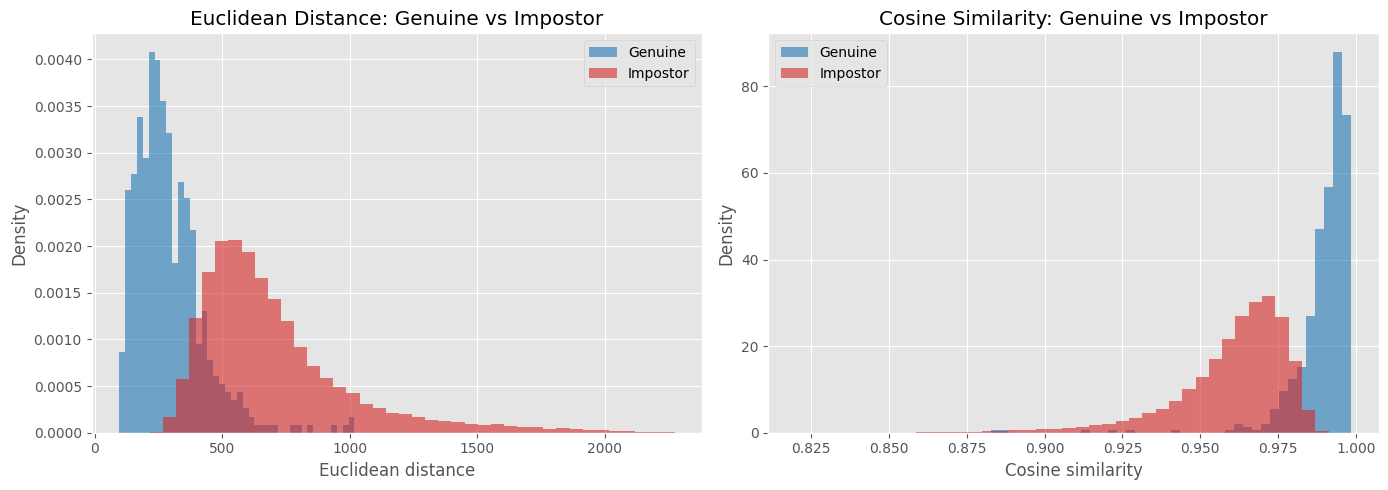

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(eu_gen, bins=40, alpha=0.6, density=True, label="Genuine", color="tab:blue")
axes[0].hist(eu_imp, bins=40, alpha=0.6, density=True, label="Impostor", color="tab:red")
axes[0].set_title("Euclidean Distance: Genuine vs Impostor")
axes[0].set_xlabel("Euclidean distance")
axes[0].set_ylabel("Density")
axes[0].legend()

axes[1].hist(co_gen, bins=40, alpha=0.6, density=True, label="Genuine", color="tab:blue")
axes[1].hist(co_imp, bins=40, alpha=0.6, density=True, label="Impostor", color="tab:red")
axes[1].set_title("Cosine Similarity: Genuine vs Impostor")
axes[1].set_xlabel("Cosine similarity")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.savefig("genuine_impostor_distributions.png", dpi=150)
plt.show()

## C & D. FAR and FRR vs Threshold


In [11]:
def far_frr_curve(genuine, impostor, thresholds, lower_is_match=True):
    far, frr = [], []
    for t in thresholds:
        if lower_is_match:
            far.append(np.mean(impostor <= t))
            frr.append(np.mean(genuine > t))
        else:
            far.append(np.mean(impostor >= t))
            frr.append(np.mean(genuine < t))
    return np.array(far), np.array(frr)

eu_thresh = np.linspace(min(eu_gen.min(), eu_imp.min()), max(eu_gen.max(), eu_imp.max()), 2000)
eu_far, eu_frr = far_frr_curve(eu_gen, eu_imp, eu_thresh, lower_is_match=True)

co_thresh = np.linspace(min(co_gen.min(), co_imp.min()), max(co_gen.max(), co_imp.max()), 2000)
co_far, co_frr = far_frr_curve(co_gen, co_imp, co_thresh, lower_is_match=False)

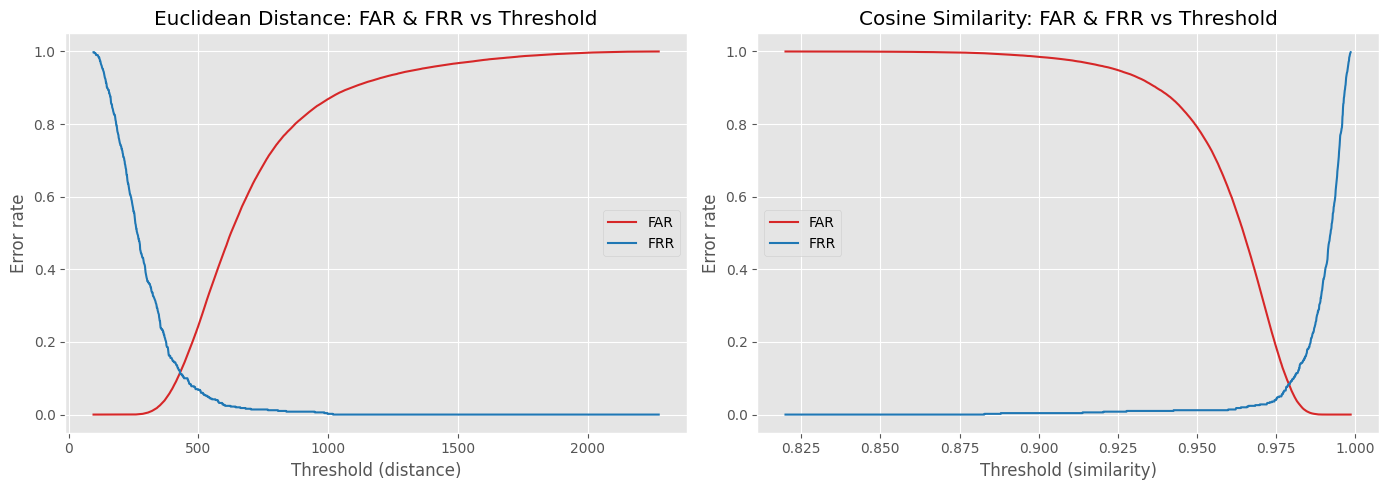

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(eu_thresh, eu_far, label="FAR", color="tab:red")
axes[0].plot(eu_thresh, eu_frr, label="FRR", color="tab:blue")
axes[0].set_title("Euclidean Distance: FAR & FRR vs Threshold")
axes[0].set_xlabel("Threshold (distance)")
axes[0].set_ylabel("Error rate")
axes[0].legend()

axes[1].plot(co_thresh, co_far, label="FAR", color="tab:red")
axes[1].plot(co_thresh, co_frr, label="FRR", color="tab:blue")
axes[1].set_title("Cosine Similarity: FAR & FRR vs Threshold")
axes[1].set_xlabel("Threshold (similarity)")
axes[1].set_ylabel("Error rate")
axes[1].legend()

plt.tight_layout()
plt.savefig("far_frr_curves.png", dpi=150)
plt.show()

**Observations (C & D):**
- For Euclidean distance the FAR and FRR curves cross around an error rate of **~0.115** (11.5%).
- For Cosine similarity at around **~0.084**
  (8.4%), indicating a threshold exists where cosine similarity makes fewer combined errors than
  Euclidean distance at its own best operating point.

## E. Receiver Operating Characteristic (ROC)

Euclidean distance is negated before computing the ROC so that, consistently with cosine similarity, a higher score always
means "more likely genuine".

TP vs FP graph


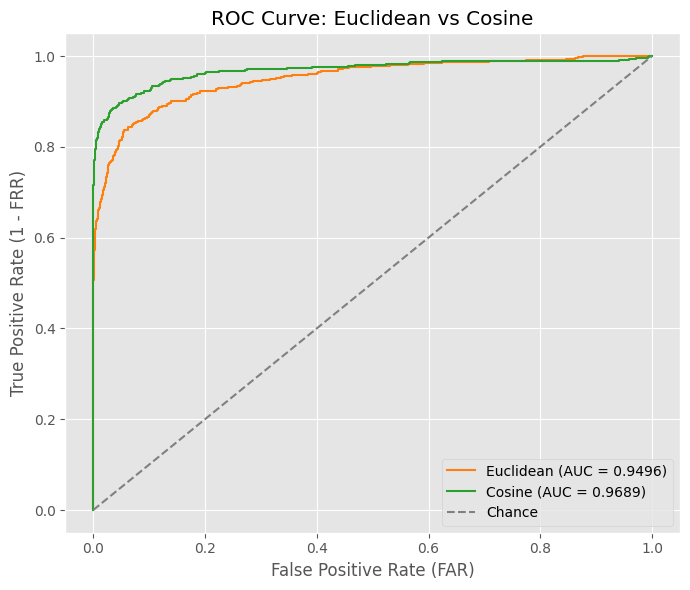

AUC (Euclidean) : 0.9496
AUC (Cosine)    : 0.9689


In [ ]:
y_true = np.array([1]*len(eu_gen) + [0]*len(eu_imp))

eu_roc_scores = np.concatenate([-eu_gen, -eu_imp])   # negate distance
fpr_eu, tpr_eu, _ = roc_curve(y_true, eu_roc_scores)
auc_eu = auc(fpr_eu, tpr_eu)

co_roc_scores = np.concatenate([co_gen, co_imp])
fpr_co, tpr_co, _ = roc_curve(y_true, co_roc_scores)
auc_co = auc(fpr_co, tpr_co)

plt.figure(figsize=(7, 6))
plt.plot(fpr_eu, tpr_eu, label=f"Euclidean (AUC = {auc_eu:.4f})", color="tab:orange")
plt.plot(fpr_co, tpr_co, label=f"Cosine (AUC = {auc_co:.4f})", color="tab:green")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
plt.xlabel("False Positive Rate (FAR)")
plt.ylabel("True Positive Rate (1 - FRR)")
plt.title("ROC Curve: Euclidean vs Cosine")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()

print(f"AUC (Euclidean) : {auc_eu:.4f}")
print(f"AUC (Cosine)    : {auc_co:.4f}")

top-left corner bowed = perfect classifier, so both are good classifiers

## F. Equal Error Rate (EER) and Decidability Index
EER = point where FAR = FRR 

**Decidability index (d')** measures how well-separated the genuine and impostor score
distributions are:

d' = |mean_genuine - mean_impostor| / sqrt(0.5 * (var_genuine + var_impostor))

Higher d' means better separation, and therefore a better-performing distance metric.

In [14]:
def eer_from_curves(thresholds, far, frr):
    diff = far - frr
    sign_changes = np.where(np.diff(np.sign(diff)))[0]
    if len(sign_changes) == 0:
        idx = np.argmin(np.abs(diff))
        return (far[idx] + frr[idx]) / 2
    i = sign_changes[0]
    f1, f2 = far[i], far[i + 1]
    r1, r2 = frr[i], frr[i + 1]
    denom = (f1 - r1) - (f2 - r2)
    alpha = (f1 - r1) / denom if denom != 0 else 0.5
    return f1 + alpha * (f2 - f1)

def decidability_index(genuine, impostor):
    return abs(genuine.mean() - impostor.mean()) / np.sqrt(0.5 * (genuine.var() + impostor.var()))

eu_eer = eer_from_curves(eu_thresh, eu_far, eu_frr)
co_eer = eer_from_curves(co_thresh, co_far, co_frr)

eu_dprime = decidability_index(eu_gen, eu_imp)
co_dprime = decidability_index(co_gen, co_imp)

results = pd.DataFrame({
    "Metric": ["Euclidean Distance", "Cosine Similarity"],
    "EER": [eu_eer, co_eer],
    "AUC": [auc_eu, auc_co],
    "Decidability Index (d')": [eu_dprime, co_dprime],
})
display(results)

,Metric,EER,AUC,Decidability Index (d')
0,Euclidean Distance,0.11516,0.949556,1.762246
1,Cosine Similarity,0.08400,0.968943,1.925934


## Conclusion: Which Matching Distance Performs Best?

**Cosine similarity performs better than Euclidean distance on this dataset**: This is
reasonable for high-dimensional feature vectors (144 dimensions here), where
cosine similarity, which compares feature-vector's direction rather than absolute
magnitude is less sensitive to per-sample scale/intensity variation than raw Euclidean
distance.